## Inspect the dataset and show class distribution:
The dataset path is `data_raw/ageing_dataset/DATASET`, this contains all classes data in individual folders namely:

*   clear skin,
*   dark spots,
*   puffy eyes,
*   wrinkles

and we save the distribution plot in `reports` folder

Found classes and counts:
puffy eyes: 300
clear skin: 305
dark spots: 303
wrinkles: 300


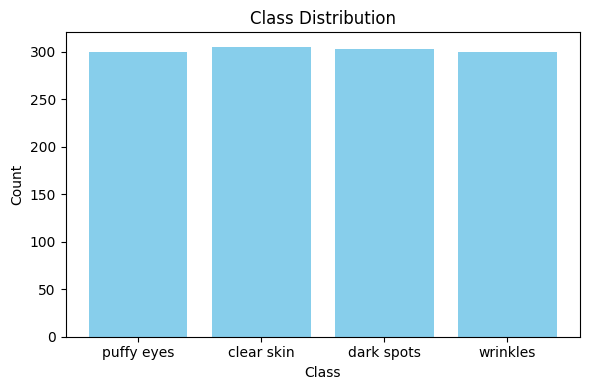

✅ Report saved to reports


In [10]:
import os, argparse, matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

def inspect_dataset(root, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    counter = Counter()

    for cls in os.listdir(root):
        cls_path = os.path.join(root, cls)
        if not os.path.isdir(cls_path):
            continue
        n_imgs = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        counter[cls] = n_imgs

    if not counter:
        print(f"No images found under {root}. Please check the path.")
        return

    print("Found classes and counts:")
    for k, v in counter.items():
        print(f"{k}: {v}")

    # Save report CSV
    df = pd.DataFrame(list(counter.items()), columns=["class", "count"])
    csv_path = os.path.join(out_dir, "class_distribution.csv")
    df.to_csv(csv_path, index=False)

    # Plot
    plt.figure(figsize=(6, 4))
    plt.bar(df["class"], df["count"], color="skyblue")
    plt.title("Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(out_dir, "class_distribution.png"))
    plt.close()

    print(f"✅ Report saved to {out_dir}")

inspect_dataset('data_raw/ageing_dataset/DATASET', 'reports')


##Data Cleaning and Preprocessing
###Data Cleaning:
####Steps Performed:



1. Color and Illumination Correction:
    - Applied CLAHE (Contrast Limited Adaptive Histogram Equalization) to improve skin contrast.
    - Applied Gamma Correction to normalize brightness and enhance subtle features.


2.   Skin Segmentation and Cropping

      - Converted images to HSV color space for skin detection.
      - Applied thresholding and morphological operations (dilation, closing) to clean masks.
      - Cropped the image to the largest skin region, removing background, hair, or clothing.

3.   Feature Enhancement

      - Applied Gamma Correction to enhance the visibility of subtle aging signs.


###Preprocessing
*   Resizing:
      - All images resized to 224×224 pixels, with black padding to maintain aspect ratio.
*   Normalization:
      - Pixel values scaled to a consistent range suitable for CNNs (0–1 or normalized per channel).
      - Normalization is done while giving the input to the model, but not during preprocessing. We can't view normalized images.

**Output**: Cleaned and preprocessed images stored in `cleaned_data/` with class-wise folders.


In [16]:
import os, argparse, cv2, numpy as np
from pathlib import Path
import hashlib
import os, cv2, numpy as np, pandas as pd
from PIL import Image

def list_images_in_dir(root):
    out = []
    for cls in sorted(os.listdir(root)):
        p = os.path.join(root, cls)
        if os.path.isdir(p):
            for f in os.listdir(p):
                if f.lower().endswith(('.jpg','.jpeg','.png','bmp','webp')):
                    out.append((os.path.join(p,f), cls))
    return out

def read_image(path, to_rgb=True):
    img = cv2.imdecode(np.fromfile(path, dtype=np.uint8), cv2.IMREAD_COLOR)
    if img is None:
        raise IOError(f"Cannot read {path}")
    if to_rgb:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def save_image(path, arr):
    # use imencode + tofile to support unicode paths on Windows
    arr_bgr = cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)
    ext = os.path.splitext(path)[1]
    _, enc = cv2.imencode(ext, arr_bgr)
    enc.tofile(path)

def apply_clahe_rgb(img_rgb):
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l2 = clahe.apply(l)
    lab2 = cv2.merge((l2,a,b))
    img2 = cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)
    return img2

def gamma_correction(img_rgb, gamma=1.0):
    invGamma = 1.0 / gamma
    table = (np.arange(256) / 255.0) ** invGamma * 255
    table = np.clip(table,0,255).astype("uint8")
    return cv2.LUT(img_rgb, table)

def skin_mask_from_hsv(img_rgb):
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    h,s,v = cv2.split(hsv)
    # broad skin range (tweak for your dataset)
    lower = np.array([0, 15, 40])
    upper = np.array([25, 200, 255])
    mask = cv2.inRange(hsv, lower, upper)
    # morphological cleanup
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(7,7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    return mask

def crop_to_largest_mask_region(img_rgb, mask, pad=10):
    # find contours and crop bounding box of largest connected region
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img_rgb  # fallback
    areas = [cv2.contourArea(c) for c in contours]
    idx = np.argmax(areas)
    x,y,w,h = cv2.boundingRect(contours[idx])
    x0 = max(0, x-pad); y0 = max(0, y-pad)
    x1 = min(img_rgb.shape[1], x+w+pad); y1 = min(img_rgb.shape[0], y+h+pad)
    return img_rgb[y0:y1, x0:x1]

def make_square_and_resize(img_rgb, size=224, pad_color=(0,0,0)):
    h, w = img_rgb.shape[:2]

    # Determine padding
    if h == w:
        sq = img_rgb
    else:
        diff = abs(h - w)
        if h > w:
            pad_left = diff // 2
            pad_right = diff - pad_left
            sq = cv2.copyMakeBorder(img_rgb, 0, 0, pad_left, pad_right, cv2.BORDER_CONSTANT, value=pad_color)
        else:
            pad_top = diff // 2
            pad_bottom = diff - pad_top
            sq = cv2.copyMakeBorder(img_rgb, pad_top, pad_bottom, 0, 0, cv2.BORDER_CONSTANT, value=pad_color)

    # Resize to target size
    resized = cv2.resize(sq, (size, size), interpolation=cv2.INTER_LINEAR)
    return resized

def normalize_imagenet_like(img_rgb, mean=0.5, std=0.5):
    # maps 0-255 to -1..1 if mean=0.5,std=0.5
    arr = img_rgb.astype('float32')/255.0
    arr = (arr - mean) / std
    return arr

def file_hash(path):
    h = hashlib.sha256()
    with open(path,'rb') as f:
        while True:
            chunk = f.read(8192)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

def preprocess_image(path, settings):
    img = read_image(path)

    # 3. color/illum corrections
    if settings['clahe']:
        img = apply_clahe_rgb(img)

    # 7. Gamma Correction
    if settings['gamma'] != 1.0:
        img = gamma_correction(img, settings['gamma'])

    # 4. Skin segmentation and crop
    mask = skin_mask_from_hsv(img)
    img_cropped = crop_to_largest_mask_region(img, mask)

    # Resize
    img_final = make_square_and_resize(img_cropped, settings['size'])

    # # normalize for CNN
    # # Normalization is for feeding the model, not for displaying images.
    # img_final = normalize_imagenet_like(img_final)

    return img_final


def preprocess_dataset(input_dir, out_dir, size=224, clahe=True, gamma=1.0):
    pairs = list_images_in_dir(input_dir)
    print(len(pairs))
    os.makedirs(out_dir, exist_ok=True)
    seen_hashes = set()
    for src, cls in pairs:
        try:
            img_proc = preprocess_image(src, {'clahe':clahe,'gamma':gamma,'size':size})
        except Exception as e:
            print("Skipping corrupt or unreadable:", src, e)
            continue
        # deduplicate simple file-hash check of original
        h = file_hash(src)
        if h in seen_hashes:
            continue
        seen_hashes.add(h)
        # save
        cls_dir = os.path.join(out_dir, cls)
        os.makedirs(cls_dir, exist_ok=True)
        fname = Path(src).stem + ".png"
        save_image(os.path.join(cls_dir, fname), img_proc)
    print("Preprocessing complete. Saved to", out_dir)

preprocess_dataset("data_raw/ageing_dataset/DATASET", "cleaned_data", 224, True, 1.0)

# if __name__ == "__main__":
#     parser = argparse.ArgumentParser()
#     parser.add_argument("--input", default="data_raw")
#     parser.add_argument("--out", default="cleaned_data")
#     parser.add_argument("--size", type=int, default=224)
#     parser.add_argument("--no-clahe", dest="clahe", action='store_false')
#     parser.add_argument("--gamma", type=float, default=1.0)
#     args = parser.parse_args()
#     main(args.input, args.out, args.size, args.clahe, args.gamma)



1208
Preprocessing complete. Saved to cleaned_data


##Data Augmentation

*   Deterministic augmentations applied to all cleaned images (`cleaned_data/`):
      - Horizontal Flip
      - Rotation (±15°)
      - Zoom/Scale (±15%)
*   Purpose:
      - Increase dataset size and improve model generalization.
      - Each image gets three augmented versions with descriptive filenames, e.g., _flip, _rot, _zoom.

*   Output: Augmented dataset stored in `augmented_data/`.

In [18]:
import os, argparse
from pathlib import Path
import albumentations as A

def get_augmenters():
    """
    Returns individual augmenters:
    - Horizontal flip
    - Rotation
    - Zoom (scale)
    """
    aug_flip = A.HorizontalFlip(p=1.0)      # always apply flip
    aug_rotate = A.Rotate(limit=15, p=1.0)  # rotate ±15°
    aug_zoom = A.ShiftScaleRotate(shift_limit=0, scale_limit=0.15, rotate_limit=0, p=1.0)  # zoom ±15%
    return aug_flip, aug_rotate, aug_zoom

def augment_all_images(clean_dir, out_dir):
    """
    Augment every image in clean_dir using flip, rotate, and zoom.
    Saves originals and augmented images to out_dir.
    """
    pairs = list_images_in_dir(clean_dir)
    class_map = {}
    for p, c in pairs:
        class_map.setdefault(c, []).append(p)

    aug_flip, aug_rotate, aug_zoom = get_augmenters()
    os.makedirs(out_dir, exist_ok=True)

    for cls, files in class_map.items():
        cls_out = os.path.join(out_dir, cls)
        os.makedirs(cls_out, exist_ok=True)

        for src in files:
            img = read_image(src)
            fname = Path(src).stem

            # save original
            save_image(os.path.join(cls_out, f"{fname}.png"), img)

            # flip
            img_flip = aug_flip(image=img)['image']
            save_image(os.path.join(cls_out, f"{fname}_flip.png"), img_flip)

            # rotate
            img_rotate = aug_rotate(image=img)['image']
            save_image(os.path.join(cls_out, f"{fname}_rot.png"), img_rotate)

            # zoom
            img_zoom = aug_zoom(image=img)['image']
            save_image(os.path.join(cls_out, f"{fname}_zoom.png"), img_zoom)

        print(f"{cls}: {len(files)} originals augmented with flip, rotate, zoom")

    print("Augmentation finished.")

augment_all_images("cleaned_data", "augmented_data")


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


clear skin: 305 originals augmented with flip, rotate, zoom
dark spots: 272 originals augmented with flip, rotate, zoom
puffy eyes: 247 originals augmented with flip, rotate, zoom
wrinkles: 254 originals augmented with flip, rotate, zoom
Augmentation finished.


###One-Hot Encoding
Class-to-index mapping: `{'clear skin': 0, 'dark spots': 1, 'puffy eyes': 2, 'wrinkles': 3}`
Convert class labels to one-hot vectors.

In [19]:
import os
import numpy as np

# Path to dataset
data_dir = "augmented_data/"

# Get class names sorted
classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
print("Classes:", classes)

# Map class names to indices
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}
print("Class to index mapping:", class_to_idx)

# Example: collect images and their labels
image_paths = []
labels = []

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    for img_file in os.listdir(cls_path):
        if img_file.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(cls_path, img_file))
            labels.append(class_to_idx[cls])

# Convert labels to NumPy array
labels = np.array(labels)

# One-hot encode labels
num_classes = len(classes)
one_hot_labels = np.eye(num_classes)[labels]

print("Example one-hot label for first image:", one_hot_labels[1221])


Classes: ['clear skin', 'dark spots', 'puffy eyes', 'wrinkles']
Class to index mapping: {'clear skin': 0, 'dark spots': 1, 'puffy eyes': 2, 'wrinkles': 3}
Example one-hot label for first image: [0. 1. 0. 0.]
